In [2]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv

c:\Users\91815\Desktop\learningLANGGRAPH\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [3]:
load_dotenv()

True

In [4]:
model=ChatGroq(model="openai/gpt-oss-120b")

In [5]:
# MessagesState is a special state type that automatically includes a messages field. This field is a list of messages (like human or AI messages) and already includes a reducer that appends new messages as the state is updated.
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {
        "messages": [response]
        }

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

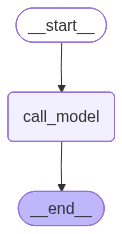

In [7]:
graph= builder.compile()
graph

In [8]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Bhavya."}]})

{'messages': [HumanMessage(content='Hi! My name is Bhavya.', additional_kwargs={}, response_metadata={}, id='5d7e8631-f567-4feb-95c1-a5183897a661'),
  AIMessage(content='Hello Bhavya! 👋 Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hi! My name is Bhavya." We need to respond appropriately. There\'s no disallowed content. Just greet and maybe ask how can I help. Use friendly tone.'}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 80, 'total_tokens': 148, 'completion_time': 0.151024789, 'completion_tokens_details': {'reasoning_tokens': 40}, 'prompt_time': 0.002985565, 'prompt_tokens_details': None, 'queue_time': 0.04720946, 'total_time': 0.154010354}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6588-bd2a-7532-b384-3fd4fbe3f083-0', tool_calls=[], invalid_tool

In [9]:
# this is without the persistence inmemory saver
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='29b6bfe8-0599-462f-a0b3-8a0124a14265'),
  AIMessage(content='I don’t know your name. If you’d like me to address you personally, just let me know what you’d like to be called!', additional_kwargs={'reasoning_content': 'The user asks "What is my name?" No prior conversation. We have no info. According to policy, we must say we don\'t know. We can ask for clarification. So respond: I don\'t know your name. If you tell me, I can address you.'}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 76, 'total_tokens': 169, 'completion_time': 0.200047111, 'completion_tokens_details': {'reasoning_tokens': 55}, 'prompt_time': 0.003439534, 'prompt_tokens_details': None, 'queue_time': 0.049818541, 'total_time': 0.203486645}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 

In [10]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}
    

In [11]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [12]:
#Introduced the inmemorysaver this is called a ram memory saver when ram gets cleared the message too.
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [13]:
config = {"configurable":{"thread_id":"thread1"}}
config2 = {"configurable":{"thread_id":"thread2"}}

In [ ]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is bhavya."}]}, config)

In [14]:
graph.invoke({"messages":[{"role":"user","content":"Hi! My name is Bhavya."}]},config=config)


{'messages': [HumanMessage(content='Hi! My name is Bhavya.', additional_kwargs={}, response_metadata={}, id='13c19044-749e-415e-a0bf-8e1d266b9c88'),
  AIMessage(content='Hello Bhavya! 👋 Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hi! My name is Bhavya." The assistant should respond politely, perhaps greeting and asking how can help. No policy violation. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 80, 'total_tokens': 143, 'completion_time': 0.134183056, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.002983955, 'prompt_tokens_details': None, 'queue_time': 0.055100359, 'total_time': 0.137167011}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4a19b1544c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6588-d85d-7be2-9724-b1b1ffd01ef2-0', tool_calls=[], invalid_tool_calls=[]

In [15]:
graph.invoke({"messages":[{"role":"user","content":"wht is my name"}]},config=config)
# see in this the inmemorysaver is thread scope if u change the threadid its new

{'messages': [HumanMessage(content='Hi! My name is Bhavya.', additional_kwargs={}, response_metadata={}, id='13c19044-749e-415e-a0bf-8e1d266b9c88'),
  AIMessage(content='Hello Bhavya! 👋 Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hi! My name is Bhavya." The assistant should respond politely, perhaps greeting and asking how can help. No policy violation. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 80, 'total_tokens': 143, 'completion_time': 0.134183056, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.002983955, 'prompt_tokens_details': None, 'queue_time': 0.055100359, 'total_time': 0.137167011}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4a19b1544c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6588-d85d-7be2-9724-b1b1ffd01ef2-0', tool_calls=[], invalid_tool_calls=[]

In [16]:
# the problem with the inmemory saver is if the ram gets cleared the data to it doesn't hold the previous conversation 
graph.invoke({"messages":[{"role":"user","content":"wht is my name"}]},config=config2)

{'messages': [HumanMessage(content='wht is my name', additional_kwargs={}, response_metadata={}, id='2336a808-88a1-4437-a11e-31944d6c3320'),
  AIMessage(content='I don’t have any information about your name. If you’d like, you can tell me what you’d like to be called, and I’ll use that going forward!', additional_kwargs={'reasoning_content': 'The user asks "wht is my name". There\'s no prior context. According to policy, we cannot reveal personal data. We don\'t have the user\'s name. So we should respond politely that we don\'t know the name. Possibly ask if they\'d like to share. Ensure not to fabricate.'}, response_metadata={'token_usage': {'completion_tokens': 102, 'prompt_tokens': 76, 'total_tokens': 178, 'completion_time': 0.217915356, 'completion_tokens_details': {'reasoning_tokens': 58}, 'prompt_time': 0.003346858, 'prompt_tokens_details': None, 'queue_time': 0.055392131, 'total_time': 0.221262214}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'se

In [17]:
snap = graph.get_state(config)
vals = snap.values
print(f"{config}  - as per config thread1 has all the message ") 
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

{'configurable': {'thread_id': 'thread1'}}  - as per config thread1 has all the message 
- HumanMessage : Hi! My name is Bhavya.
- AIMessage : Hello Bhavya! 👋 Nice to meet you. How can I assist you today?
- HumanMessage : wht is my name
- AIMessage : Your name is **Bhavya**. Let me know if there’s anything else you’d like to talk about!


In [ ]:
snap = graph.get_state(config2)
vals = snap.values
print(f"{config2}  - as per config thread2 has all the messages ") 
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

{'configurable': {'thread_id': 'thread2'}}  - as per config thread2 has all the message 
- HumanMessage : wht is my name
- AIMessage : I don’t have any information about your name. If you’d like, you can tell me what you’d like to be called, and I’ll use that going forward!
